In [30]:
# İnternetten bir Türkçe isim listesi bul (açık kaynak listeler var, GitHub'da arayabilirsin) ve iki modeli de bu veriyle tekrar
#koştur. Alfabeyi Türkçe karakterlerle genişlet (ç, ğ, ı, ö, ş, ü). Modelin ürettiği isimlerden örnekleri ve loss'u göster.

In [42]:
#core
words = open('isimler_unique.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}


In [32]:
import torch
import torch.nn.functional as F
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()

In [33]:
# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((30, 30), generator=g, requires_grad=True)

In [34]:
losses = []
for i in range(101):
    # forward pass
    xenc = F.one_hot(xs, num_classes=30).float() # input to the network: one-hot encoding
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
    loss = -probs[torch.arange(num), ys].log().mean() 
    
    
    # backward pass
    W.grad = None # set to zero the gradient
    loss.backward()
    losses.append(loss.item())
    if i % 10 == 0: #first and every 10th iterations print.     
        print(f"step {i}: loss = {loss.item()}")
    
    # update
    W.data += -50 * W.grad


step 0: loss = 3.9728710651397705
step 10: loss = 2.770328998565674
step 20: loss = 2.61933970451355
step 30: loss = 2.566236972808838
step 40: loss = 2.5404419898986816
step 50: loss = 2.5257604122161865
step 60: loss = 2.5165398120880127
step 70: loss = 2.5102896690368652
step 80: loss = 2.5057857036590576
step 90: loss = 2.502380847930908
step 100: loss = 2.499708414077759


In [43]:
N = torch.zeros(30,30, dtype=torch.int32)

for w in words:
    chs = ["."] + list(w) + ["."] 
    for ch1, ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2,] += 1 


P = (N).float() #without smoothing
P = P/ P.sum(1, keepdims=True)

In [44]:
log_likelihood = 0.0
n = 0

for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    log_likelihood += logprob # log[p(a) * p(b) * p(c)] = log[p(a)] + log[p(b)] + log[p(c)]
    n += 1
nll = -log_likelihood
print(f'{nll/n}') #avg negative loglikelihood.

2.476231813430786


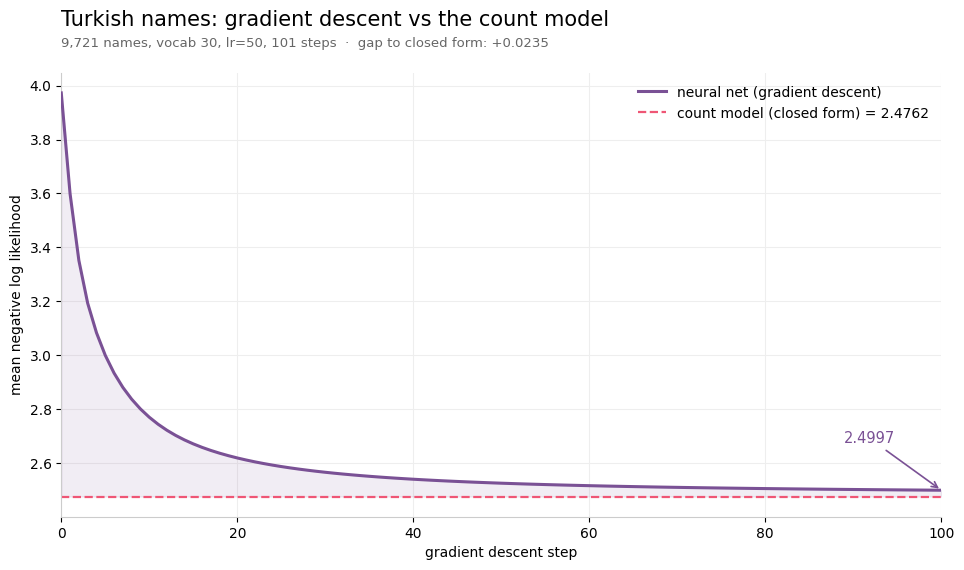

In [46]:
import matplotlib.pyplot as plt

target = -P[xs, ys].log().mean().item()  
V = len(stoi)

plt.rcParams.update({"font.size": 10})
fig, ax = plt.subplots(figsize=(10, 6))
fig.subplots_adjust(left=.09, right=.97, top=.85, bottom=.11)

ax.plot(losses, color="#7a5195", linewidth=2.2, zorder=3, label="neural net (gradient descent)")
ax.axhline(target, color="#ef5675", linestyle="--", linewidth=1.6, zorder=2,
           label=f"count model (closed form) = {target:.4f}")
ax.fill_between(range(len(losses)), target, losses, color="#7a5195", alpha=.10, zorder=1)

ax.set_xlabel("gradient descent step")
ax.set_ylabel("mean negative log likelihood")
ax.set_xlim(0, len(losses)-1)
ax.grid(color="#eeeeee", zorder=0); ax.set_axisbelow(True)
for s in ("top", "right"): ax.spines[s].set_visible(False)
for s in ("left", "bottom"): ax.spines[s].set_color("#cccccc")
ax.legend(frameon=False, loc="upper right", fontsize=10)

ax.annotate(f"{losses[-1]:.4f}", xy=(len(losses)-1, losses[-1]),
            xytext=(-70, 34), textcoords="offset points", fontsize=10.5, color="#7a5195",
            arrowprops=dict(arrowstyle="->", color="#7a5195", lw=1.2))

fig.suptitle("Turkish names: gradient descent vs the count model", x=.09, ha="left", fontsize=15, y=.955)
fig.text(.09, .893, f"{len(words):,} names, vocab {V}, lr=50, {len(losses)} steps  ·  "
                    f"gap to closed form: {losses[-1]-target:+.4f}", fontsize=9.5, color="#666");

In [52]:

#2 models samples first one is nets.
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  
  out = []
  ix = 0
  while True:
    
    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=30).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))


print("----------------")

g = torch.Generator().manual_seed(2147483647) #forgot that line first. Was hard to catch

for i in range(5):
  
  out = []
  ix = 0
  while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

güsu.
oçmerslbi.
te.
ören.
yhimur.
----------------
güsu.
oçmerslbi.
te.
ören.
yhimur.
